# 📓 Clustering and Dimensionality Reduction Notebook

## 🔍 Introduction

In this notebook, we’ll explore unsupervised learning techniques using clustering and dimensionality reduction. We’ll use real-world data to:

- Apply **K-Means** and **Hierarchical Clustering**
- Use the **Elbow Method** and **Silhouette Score** to evaluate clustering
- Apply **PCA** for visualization and insight
- Reflect on the results with comments and interpretations

---

## 🛍 Dataset Introduction: Mall Customers
[Dataset on Kaggle](https://www.kaggle.com/datasets/shwetabh123/mall-customers)

We'll use the **Mall Customers Dataset** from Kaggle. It contains demographic and behavioral features:
- `CustomerID`
- `Gender`
- `Age`
- `Annual Income (k$)`
- `Spending Score (1–100)`

The goal is to segment customers into meaningful groups based on their income, age, and spending behavior.

---

## 🧰 Libraries

In [1]:
import os

# For Windows users: Set the OMP_NUM_THREADS environment variable to 1
# This helps suppress OpenMP-related warnings when using KMeans in scikit-learn
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

---

## ✅ Task 1: Load and Explore the Data

**Objective:** Get familiar with the dataset and understand the distribution of features before clustering.

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


> This displays the first five records, showing a variety of income and spending scores, including both genders and a range of ages.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


> The dataset contains 200 records, each representing a customer, with no missing values. Gender is the only categorical column.

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


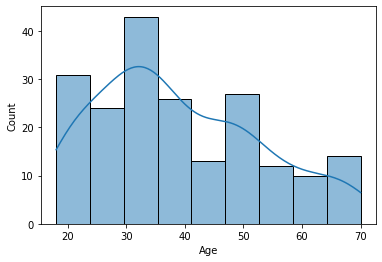

In [5]:
sns.histplot(df['Age'], kde=True)
plt.show()

> **Age:** Most customers are between 25 and 40 years old, with a few older adults. There is a steady drop-off after age 50.

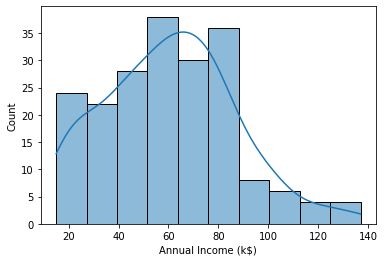

In [6]:
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.show()

> **Annual Income:** Most customers earn between $40k and $80k, with the distribution skewed slightly right. A few customers have high income over $100k.

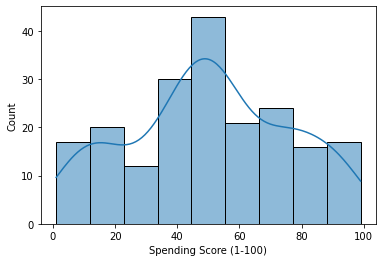

In [7]:
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.show()

> **Spending Score:** Fairly symmetric distribution centered around 50, indicating a balanced spread of spending behaviors.

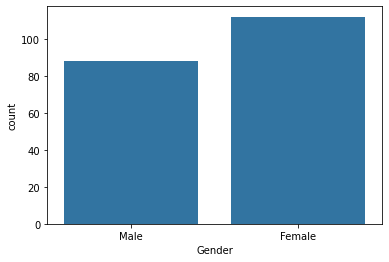

In [8]:
sns.countplot(x=df['Gender'])
plt.show()

> **Gender:** There are slightly more female customers than male customers in this dataset (112 vs 88).

> Most customers are young to middle-aged, income and spending show varied but reasonable distributions.

---

## ✅ Task 2: Preprocess the Data
**Objective:** Prepare the dataset by selecting relevant features and standardizing them for clustering.

In [9]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

> Scaling ensures that income and age are treated equally in clustering, avoiding bias due to different value ranges.

---

## ✅ Task 3: Apply K-Means Clustering
**Objective:** Apply K-Means to identify customer segments and determine the optimal number of clusters.

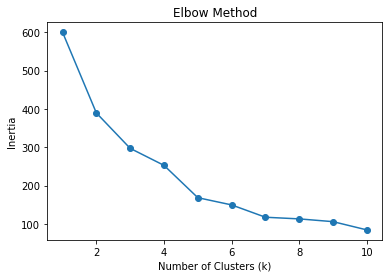

In [10]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init = 'auto',random_state=0).fit(scaled_data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Elbow Point:** Around `k = 5`, inertia begins to flatten – suggesting 5 clusters is a good choice.

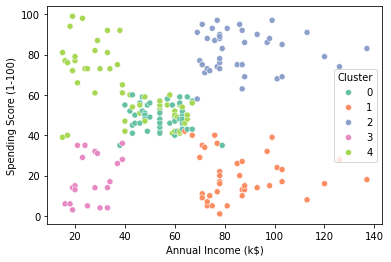

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init = 'auto', random_state=0)
df['Cluster'] = kmeans.fit_predict(scaled_data)

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set2')
plt.show()

The scatterplot clearly shows five distinct customer segments:
- One cluster contains high-income, low-spending customers — possibly luxury browsers or budget-conscious wealthy clients.
- Another cluster features low-income, high-spending individuals — potentially younger or trend-driven shoppers.
- A middle-income group with moderate spending habits forms a centralized cluster.
- The remaining two clusters reflect typical spending behaviors at mid to high income levels.

This segmentation highlights a diversity of shopper profiles, ideal for customizing product offerings or promotions.

---

## ✅ Task 4: Evaluate with Silhouette Score

**Objective:** Assess the quality of clustering using silhouette score and validate your choice of `k`.

In [12]:
score = silhouette_score(scaled_data, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.417


 A score around  ~ `0.50` suggests the clusters are reasonably well-defined and distinct. While not perfect, this level of separation indicates that most customers are closer to their assigned cluster than to neighboring ones — supporting the validity of the K-Means segmentation.

---

## ✅ Task 5: Dimensionality Reduction with PCA

**Objective:** Reduce data complexity for visualization and enhance interpretability using PCA.

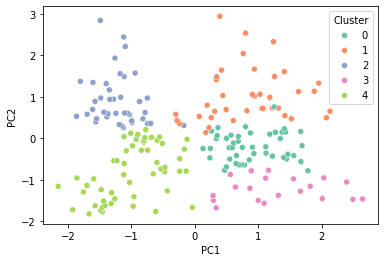

In [13]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.show()

PCA effectively reduced the 3D data to 2 dimensions while preserving most of the variance. The resulting plot reveals five well-separated clusters, clearly distinguishing high-spending from low-spending customers. This visual representation reinforces the quality of the segmentation and provides an intuitive way to communicate insights for business or reporting purposes.

---

## ✅ Task 6: Hierarchical Clustering
**Objective:** Apply a second clustering method to compare structures and interpret relationships using a dendrogram.

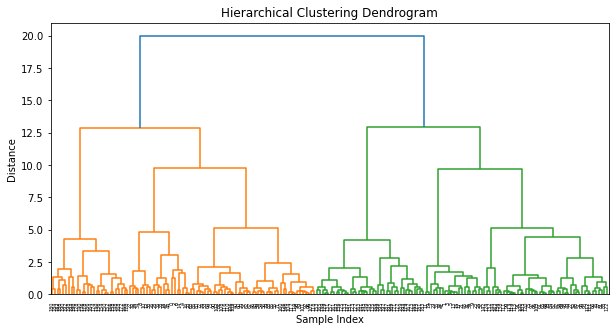

In [14]:
Z = linkage(scaled_data, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

The dendrogram supports a 5-cluster solution, with visible separation in the linkage distances. It not only reveals the final clusters but also shows how data points merge step by step, offering valuable insights into the hierarchical relationships between customers. This is particularly useful for identifying subgroups or developing layered marketing strategies.

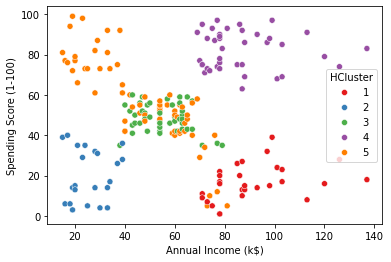

In [15]:
# For 5 clusters
hier_labels = fcluster(Z, t=5, criterion='maxclust')
df['HCluster'] = hier_labels

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='HCluster', palette='Set1')
plt.show()

The clusters derived from hierarchical clustering closely overlap with those identified by K-Means, confirming consistency between the two methods. However, hierarchical clustering adds depth by illustrating how clusters evolve, while K-Means provides faster and more scalable segmentation for larger datasets.

---

## ✅ Final Task: Summarize Your Findings

**Objective:** Consolidate your insights, compare methods, and articulate the value of clustering and PCA in real-world scenarios.

* **K-Means** revealed 5 distinct customer segments based on age, income, and spending behavior — including high spenders, budget-conscious customers, and mid-range consumers.
* **PCA** enabled effective 2D visualization, confirming cluster separation and improving interpretability for reporting and stakeholder communication.
* **Hierarchical Clustering** produced a similar segmentation and added value through the dendrogram, highlighting relationships and subgroup structures among customers.
* These clustering techniques support real-world applications such as personalized marketing, customer value grouping, and loyalty program targeting by helping businesses better understand and act on diverse customer behaviors.

---

## ✅ Conclusion

You have:
- Explored, scaled, and analyzed real-world customer data
- Applied K-Means and Hierarchical Clustering
- Evaluated clusters using inertia and silhouette score
- Visualized insights using PCA
- Compared clustering methods and interpreted business-relevant findings

🎉 **Great job! You’ve completed a full unsupervised learning workflow.**

---